# Chapter F. Statistical Simulation and Validation

## Learning Objectives

After completing this chapter, you should be able to:
1. Design a known-truth generator with null and alternative conditions.
2. Distinguish complete-null calibration, mixed-null FDR, and planted-mechanism recovery.
3. Estimate Monte Carlo uncertainty from independent replications.
4. Perform factorial sensitivity checks for overlap, persistence, and signal strength.
5. Write an honest interpretation of when a randomization reference fails.

**Connection to STARM:** The examples mirror the binary outcome, fixed antecedent indicators, lagged transactions, and overlapping spatial supports in the STARM manuscript. They are teaching examples, not reproductions of manuscript results.

> **Teaching philosophy:** start with the general statistical problem, build mathematical intuition, and use STARM as one illustrative case study. The new sections precede the original computational labs.

## Why Study This? — Motivation, Scope, and Real-World Problems

A method may look reliable on one dataset yet systematically produce false positives, miss weak signals, or break under changed sampling conditions. **Simulation-based validation (模拟验证)** uses controlled data-generating processes to measure these properties when truth is known. It is central to new statistical estimators, algorithms, medical trial designs, and spatial inference methods.

**Questions it answers:** Are p-values calibrated? Is the algorithm powerful enough? Do findings survive assumption violations? Is the study large enough to measure uncertainty in the evaluation itself?

---

## Conceptual Roadmap

**Scientific problem → statistical representation → assumptions → mathematics → computational experiment → diagnostics → interpretation.**

The chapters are standalone: STARM is a later application, not the reason these mathematical ideas exist.

## Foundations and Mathematical Derivations

### A simulation study is a designed experiment
Separate (1) **data generator**, (2) **estimator or test**, (3) **performance estimand**, (4) **replicate design**, and (5) **reporting uncertainty**. A good simulation compares methods under matched data and systematically varies a small number of factors.

### Operating characteristics
For true parameter $\theta$ and estimate $\hat\theta^{(b)}$ in replicate $b$:

$$\mathrm{Bias}=E[\hat\theta]-\theta,\quad\mathrm{MSE}=E[(\hat\theta-\theta)^2]=\mathrm{Var}(\hat\theta)+\mathrm{Bias}^2.$$

For tests, report Type I error under the null, power under alternatives, and confidence-interval coverage. For multiple testing, report $\widehat{\mathrm{FDR}}=B^{-1}\sum_{b=1}^B V_b/\max(R_b,1)$, not the false share obtained by pooling all discoveries across replicates.

### Monte Carlo uncertainty is part of the answer
If $K$ of $B$ independent replicates reject under a complete null, $\widehat p=K/B$ and approximately

$$\mathrm{MCSE}(\widehat p)=\sqrt{\widehat p(1-\widehat p)/B}.$$

For general replicate-level values $z_b$ (e.g. FDP), use $\mathrm{MCSE}(\bar z)=s_z/\sqrt{B}$. Replication uncertainty is distinct from parameter uncertainty inside any single simulated dataset.

### Stress tests and factorial design
Vary sample size, signal strength, event rarity, spatial range, overlap, temporal persistence, lag count and candidate count. A factorial design separates main effects and interactions. Strong null calibration at one configuration does **not** imply validity for another.

### Calibration plots
Under a continuous valid null, p-values are Uniform(0,1). Discrete valid p-values are often conservative (super-uniform): $P(p\le u)\le u$. Plot the empirical CDF against the diagonal. For complete-null family testing, track $P(R>0)$ as well as per-test calibration.

### Reproducible experiments
Record seeds, model parameters, simulator version, exact hypothesis family and screening rules. Use new seeds for confirmatory replications, and separate exploratory tuning from the final benchmark.

### Critical thinking checkpoint
Before running code, write down which observations are assumed independent or exchangeable and explain why. Revisit this statement after inspecting the visualizations.

### Why error rates became simulation targets
A single test reports one p-value, but a method used across many hypotheses must be judged by its *repeated-study behavior*. The practical problem is that a long list of nominally significant findings can contain false claims even when every individual test appears calibrated. Bonferroni addressed the “any false claim” risk with a union-bound guarantee. Benjamini and Hochberg (1995) then asked a different question: can an exploratory discovery list control its expected false share while retaining useful power? Benjamini and Yekutieli (2001) addressed the further difficulty that test statistics may be dependent.

These methods have different estimands; a simulation must not collapse them into one number. In replicate $b$, record $V_b$ (false rejections), $S_b$ (true rejections), and $R_b=V_b+S_b$:

$$\mathrm{FDP}_b=\frac{V_b}{\max(R_b,1)},\quad\widehat{\mathrm{FDR}}=\frac1B\sum_{b=1}^B\mathrm{FDP}_b,\quad\widehat{\mathrm{FWER}}=\frac1B\sum_{b=1}^B\mathbf{1}(V_b>0).$$

Power is the average fraction of planted true alternatives rejected; Type II error is $\beta=1-\mathrm{power}$ for that specified alternative. Under the complete null every discovery is false, so FDR equals FWER; under a mixed null they differ. **Do not pool all discoveries across replicates and call that FDR**: that weights replicates with many rejections more heavily than the definition $E[\mathrm{FDP}]$.

### A validation plan that answers the original question
1. **Complete null:** generate no true signals. Check marginal p-value calibration and estimate $P(R>0)$; this is both FWER and FDR under the complete null.
2. **Mixed null:** plant a prespecified set of effects. Estimate replicate-mean FDP (FDR), FWER, and power separately. Report $\beta=1-\mathrm{power}$ for each effect/design scenario.
3. **Vary the difficult conditions:** number of tests, effect size, rarity, sample size, spatial overlap, temporal persistence, and dependence. A method that works for independent tests may fail under dependence.
4. **Quantify simulation error:** for $B$ independent replicates, Monte Carlo standard error for estimated FWER $\hat p$ is approximately $\sqrt{\hat p(1-\hat p)/B}$; for estimated FDR, use the sample standard deviation of replicate FDPs divided by $\sqrt B$.
5. **Separate calibration from discovery:** a good power result under one alternative cannot compensate for false-alarm inflation under the null. Repeat both null and alternative scenarios with the same candidate-generation pipeline used in the intended analysis.

The short example below applies all three procedures to a fixed family of five p-values. It illustrates the mechanics only; procedure guarantees still depend on valid p-values and their dependence conditions.

In [1]:
import numpy as np
import pandas as pd

example_p_values = np.array([0.001, 0.012, 0.020, 0.070, 0.40])
family_size = len(example_p_values)
target_level = 0.05
harmonic_factor = np.sum(1 / np.arange(1, family_size + 1))

bonferroni_reject = example_p_values <= target_level / family_size


def step_up_reject(p_values, level, dependence_factor=1.0):
    order = np.argsort(p_values)
    sorted_p = p_values[order]
    thresholds = (
        level * np.arange(1, len(p_values) + 1)
        / (len(p_values) * dependence_factor)
    )
    passing_ranks = np.flatnonzero(sorted_p <= thresholds)
    rejected = np.zeros(len(p_values), dtype=bool)
    if passing_ranks.size:
        rejected[order[:passing_ranks[-1] + 1]] = True
    return rejected


bh_reject = step_up_reject(example_p_values, target_level)
by_reject = step_up_reject(
    example_p_values, target_level, dependence_factor=harmonic_factor
)
comparison = pd.DataFrame({
    "p-value": example_p_values,
    "uncorrected": example_p_values <= target_level,
    "Bonferroni FWER": bonferroni_reject,
    "BH FDR": bh_reject,
    "BY arbitrary-dependence FDR": by_reject,
})
print(f"M={family_size}; target level={target_level}; H_M={harmonic_factor:.3f}")
print(comparison.to_string(index=False))
print("Rejected counts:", {
    "uncorrected": int((example_p_values <= target_level).sum()),
    "Bonferroni": int(bonferroni_reject.sum()),
    "BH": int(bh_reject.sum()),
    "BY": int(by_reject.sum()),
})

M=5; target level=0.05; H_M=2.283
 p-value  uncorrected  Bonferroni FWER  BH FDR  BY arbitrary-dependence FDR
   0.001         True             True    True                         True
   0.012         True            False    True                        False
   0.020         True            False    True                        False
   0.070        False            False   False                        False
   0.400        False            False   False                        False
Rejected counts: {'uncorrected': 3, 'Bonferroni': 1, 'BH': 3, 'BY': 1}


## Additional Derivation Visualization — General-Purpose Example

The following self-contained experiment illustrates a general statistical principle, not STARM-specific results. Check how the plot corresponds to the formulas above.

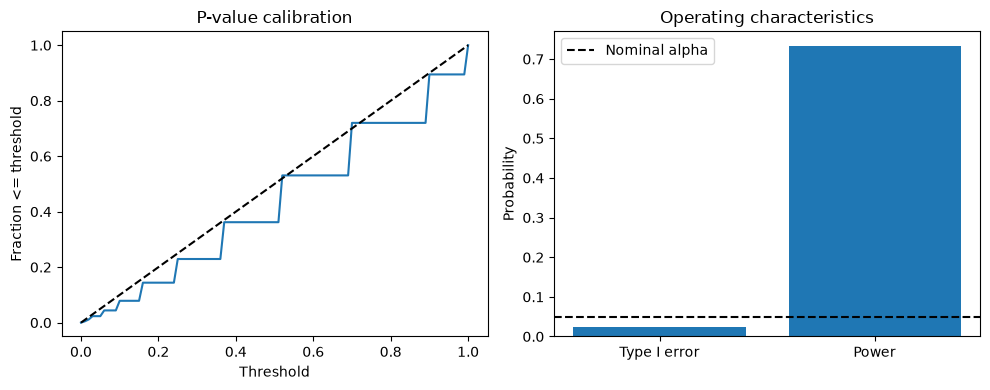

Estimated Type I error: 0.023333333333333334 MCSE: 0.0038977676422014425


In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(14)
B=1500;n=60
p_null=np.empty(B);p_alt=np.empty(B)
from scipy.stats import binomtest
for b in range(B):
 p_null[b]=binomtest(rng.binomial(n,.5),n,.5).pvalue
 p_alt[b]=binomtest(rng.binomial(n,.68),n,.5).pvalue
fig,axs=plt.subplots(1,2,figsize=(10,4))
u=np.linspace(0,1,101)
axs[0].plot(u,[(p_null<=a).mean() for a in u],label='Null empirical CDF')
axs[0].plot(u,u,'k--',label='Uniform diagonal')
axs[0].set(title='P-value calibration',xlabel='Threshold',ylabel='Fraction <= threshold')
axs[1].bar(['Type I error','Power'],[(p_null<=.05).mean(),(p_alt<=.05).mean()])
axs[1].axhline(.05,color='k',ls='--',label='Nominal alpha')
axs[1].set(title='Operating characteristics',ylabel='Probability');axs[1].legend()
plt.tight_layout();plt.show()
rate=(p_null<=.05).mean();print('Estimated Type I error:',rate,'MCSE:',np.sqrt(rate*(1-rate)/B))

```mermaid
flowchart LR
    A[Choose data-generating process] --> B[Generate X and Y]
    B --> C[Fix candidate family]
    C --> D[Apply tests and BH]
    D --> E[Compute FDP and power]
    E --> F[Replicate and quantify uncertainty]
```

This chapter follows the same structure as the supplied MCLP tutorial: conceptual workflow, formal definition, assumptions, a hand-worked example, executable Python experiments, sensitivity checks, common pitfalls, and a quiz.

---

## Formal Definition and Core Equations

### Notation

| Symbol | Meaning |
|---|---|
| $R_s$ | number of independent simulation replications |
| $B$ | permutations per replication |
| $\widehat{\pi}$ | estimated planted-rule recovery probability |
| $\widehat{FDR}$ | mean replicate FDP |
| $\mathrm{MCSE}$ | Monte Carlo standard error |

$$\widehat{FDR}=\frac1{R_s}\sum_{r=1}^{R_s}\frac{V_r}{\max(R_r,1)},\quad\mathrm{MCSE}(\widehat{FDR})=\frac{s_{\mathrm{FDP}}}{\sqrt{R_s}}.$$

For recovery proportions, an approximate MCSE is $\sqrt{\widehat\pi(1-\widehat\pi)/R_s}$; near the boundaries prefer an exact binomial interval. These intervals describe simulation uncertainty, not confidence about general model validity.

---

## Core Mechanisms and Concepts

### End-to-end evaluation

The target workflow is: generate geographic contexts, simulate point events, aggregate cylinder occupancies, screen antecedents without Y, evaluate candidate-specific nulls, and adjust the fixed family. Simplified row-data examples can test implementation but are **not** equivalent to full geographic simulation.

### Truth definitions

Distinguish *planted mechanisms* from all candidates with population lift greater than one. A conjunction containing a true signal and an irrelevant variable can still have a positive marginal association.

### Null vs alternative

Under complete null, the proportion of repetitions with any discovery is estimated FDR. Under alternative, measure mean FDP and recovery separately. A tiny mixed-null mean FDP does not override a complete-null failure.

### Reference-model validation

Exact hypergeometric and Monte Carlo row shuffling share assumptions; agreement of their outputs confirms numerical implementation, not exchangeability. Test competing reference models under matched generators and report both calibration and power.

## Assumptions, Strengths, Limitations, and Trade-offs

Assume independent simulation replicates and an explicit truth definition. Strength: direct, quantitative evaluation of false-retention and detection. Limit: performance under one generator does not generalize automatically to seasonal or heterogeneous empirical geography.

**Trade-off:** screening thresholds, signal rarity, dependency-preserving references, and multiple-testing adjustment all trade statistical power against error control.

## Worked Toy Example

Suppose a planted rule is retained in 772 of 1,000 independent simulation replicates. Recovery is 0.772 and approximate MCSE is $\sqrt{0.772(1-0.772)/1000}$. This reports precision of a simulated recovery frequency, **not** whether the reference is valid in California wildfire data.

STARM reports 2.2%, 16.9%, and 18.8% complete-null rejection for disjoint, moderate-overlap, and heavy-overlap/persistent settings. These are manuscript results; the exercises below are smaller independent teaching experiments and should not reproduce or substitute them.

## Python Lab: Set Up the Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, binom

SEED = 41020001
rng = np.random.default_rng(SEED)
print("Reproducible random seed:", SEED)

Reproducible random seed: 41020001


## Define a reusable BH evaluator

Use a correct fixed-family BH procedure; no target-driven candidate filtering.

In [4]:
def bh_reject(p,alpha=.05):
 p=np.asarray(p,float);order=np.argsort(p);m=len(p);hits=p[order]<=alpha*np.arange(1,m+1)/m
 out=np.zeros(m,dtype=bool)
 if hits.any():out[order[:np.where(hits)[0][-1]+1]]=True
 return out
print(bh_reject([.001,.03,.04,.2,.6]))

[ True False False False False]


**Interpretation.** The BH rejection set is a prefix through the largest passing sorted p-value.

## Simulation under independent complete null

Use EXACT hypergeometric tails for efficiency; candidates are fixed binary vectors.

In [5]:
def run_one_null(rng,N=240,M=24,alpha=.05):
 X=rng.binomial(1,.30,size=(N,M));Y=rng.binomial(1,.10,size=N)
 m=Y.sum();n=X.sum(axis=0);K=X.T@Y
 p=np.ones(M);good=(m>0)&(m<N)&(n>0)&(n<N)
 p[good]=hypergeom.sf(K[good]-1,N,m,n[good])
 return bh_reject(p,alpha).any()
R=550
null_rej=np.array([run_one_null(rng) for _ in range(R)])
print('Independent-row complete-null rejection:',null_rej.mean())

Independent-row complete-null rejection:

 0.03272727272727273


**Interpretation.** This generator meets a simple iid target-label null conditional on m. Null rejection proportion is an empirical FDR estimate here.

## Evaluate planted recovery and family-wide FDP

A small mixed-null model illustrates the difference between mechanism recovery and false rules.

In [6]:
def run_one_alt(rng,N=260,M=30,beta=1.3):
 X=rng.binomial(1,.35,size=(N,M));base=.06
 target_p=1-np.exp(np.log(1-base)*np.exp(beta*X[:,0]))
 Y=rng.binomial(1,target_p);m=Y.sum();n=X.sum(axis=0);K=X.T@Y
 p=np.ones(M);good=(m>0)&(m<N)&(n>0)&(n<N)
 p[good]=hypergeom.sf(K[good]-1,N,m,n[good]);rej=bh_reject(p)
 return {'planted_detected':bool(rej[0]),'FDP':rej[1:].sum()/max(1,rej.sum()),'discoveries':rej.sum()}
res=pd.DataFrame([run_one_alt(rng) for _ in range(550)])
print(res.mean(numeric_only=True).round(3))

planted_detected    0.625
FDP                 0.036
discoveries         0.693
dtype: float64


**Interpretation.** Only column 0 drives Y in this independent-predictor toy generator; the other columns are null and can be counted in FDP.

## Quantify simulation uncertainty

Compute an approximate interval for a mean replicate FDP and a binomial recovery proportion.

In [7]:
r=len(res);p_hat=res.planted_detected.mean();fdr=res.FDP.mean()
se_recovery=np.sqrt(p_hat*(1-p_hat)/r);se_fdr=res.FDP.std(ddof=1)/np.sqrt(r)
print(pd.DataFrame({'estimate':[p_hat,fdr],'MCSE':[se_recovery,se_fdr],'approx_lower':[p_hat-1.96*se_recovery,fdr-1.96*se_fdr],'approx_upper':[p_hat+1.96*se_recovery,fdr+1.96*se_fdr]},index=['Planted recovery','Mean FDP']).round(3))

                  estimate   MCSE  approx_lower  approx_upper
Planted recovery     0.625  0.021         0.585         0.666
Mean FDP             0.036  0.006         0.024         0.049


**Interpretation.** Confidence intervals quantify replication variability. More repetitions reduce MCSE but cannot fix a misspecified data-generating process.

## Sensitivity to signal strength

Measure how planted recovery changes as effects vary.

   beta  recovery    FDP
0   0.0     0.000  0.019
1   0.4     0.000  0.031
2   0.8     0.112  0.025
3   1.2     0.500  0.031
4   1.6     0.925  0.025


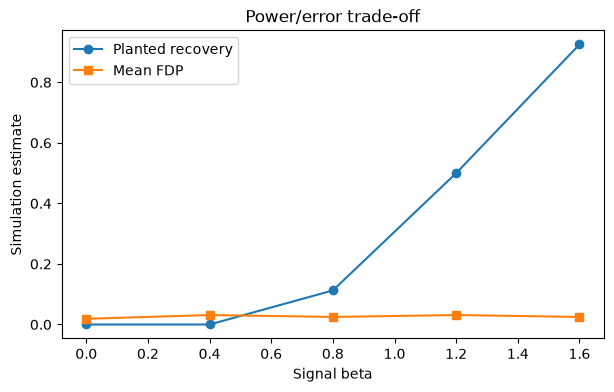

In [8]:
out=[]
for b in [0,.4,.8,1.2,1.6]:
 z=pd.DataFrame([run_one_alt(rng,beta=b) for _ in range(160)])
 out.append({'beta':b,'recovery':z.planted_detected.mean(),'FDP':z.FDP.mean()})
out=pd.DataFrame(out);print(out.round(3))
fig,ax=plt.subplots(figsize=(7,4));ax.plot(out.beta,out.recovery,marker='o',label='Planted recovery');ax.plot(out.beta,out.FDP,marker='s',label='Mean FDP');ax.set(xlabel='Signal beta',ylabel='Simulation estimate',title='Power/error trade-off');ax.legend();plt.show()

**Interpretation.** Recovery generally increases with signal strength. At beta=0 all columns are null, so the displayed FDP is still interpretable as complete-null FDP, while the column-0 “recovery” is merely false rejection, not power.

---

## Common Pitfalls and Misunderstandings

- Confusing descriptive signal recovery with valid statistical inference.
- Treating independent rows as a substitute for realistic shared-event spatial supports.
- Reporting only mixed-null FDR without complete-null calibration.
- Calling correlated candidates false when population lift is genuinely positive.
- Interpreting a narrow simulation interval as evidence that the model assumptions are true.
- Varying radius and persistence simultaneously, then attributing results to only one factor.

---

## Quiz — Self-Assessment (Answers Hidden)

Try each question before expanding **Answer**. The folded format follows the supplied `mclp.ipynb` template.

### Q1: What is the distinction between statistical uncertainty and Monte Carlo uncertainty?

A. They are always the same  
B. One concerns data-based inference; the other simulation-replication estimation error  
C. MC error is causality error  
D. Neither can be estimated

<details>
<summary>Answer</summary>

**B. Repeating simulations estimates operating characteristics with its own numerical uncertainty.**

</details>

---

### Q2: What happens if a method is calibrated under disjoint supports but not overlapping supports?

A. The method is universally valid  
B. The method has assumption-dependent validity  
C. Power must be zero  
D. Sample size is irrelevant

<details>
<summary>Answer</summary>

**B. Calibration should be reported for the actual dependence structure.**

</details>

---

### Q3: How should Monte Carlo FDR be computed over replicates?

A. Pool all false discoveries divided by all discoveries  
B. Average FDP within each replicate, including zero-discovery replicates  
C. Average the p-values  
D. Count only significant replicates

<details>
<summary>Answer</summary>

**B. FDR is the expectation of the replicate-level FDP.**

</details>

---

### Q4: What is a good way to distinguish exploratory simulation tuning from confirmation?

A. Reuse the same selected seeds  
B. Change goals after observing results  
C. Prespecify a confirmation set with new independent replications  
D. Report only favorable configurations

<details>
<summary>Answer</summary>

**C. Independent confirmation reduces optimistic evaluation from iterative tuning.**

</details>

---

### Reflection Question (no prescribed solution)

Name one assumption violation in your own research area and propose a simulation to measure how much it matters.


---

## Suggested Reading and STARM Crosswalk

- Agrawal & Srikant (1994): frequent-itemset search (background).
- Hope (1968); Phipson & Smyth (2010): randomization/Monte Carlo p-values (Chapter B).
- Benjamini & Hochberg (1995); Benjamini & Yekutieli (2001): multiple testing and dependence (Chapter C).
- Baddeley, Rubak & Turner (2015): spatial point patterns (Chapter D).
- Winkler et al. (2014): exchangeability blocks and permutation designs (Chapters B, D, E).
- STARM manuscript: Sections 3.3–3.6 for reference assumptions; Section 4 for simulations; Sections 5–6 for empirical limitations.

**Practice task:** Write a short reviewer note distinguishing a descriptive association from an inferential discovery, explicitly naming the null model and its assumptions.